In [8]:
import numpy as np
import matplotlib.pyplot as plt
from math import  log, exp, sqrt
from scipy.stats import norm

In [ ]:
def black_scholes(S,K,r,T,vol,flag):

    d1 = ( np.log(S/K) + (r + 0.5*vol**2)*T )/( vol*sqrt(T) )
    d2 = d1 - vol*sqrt(T)
    C  = S*norm.cdf(d1) - K * exp(-r*T) * norm.cdf(d2)
    P  =  K * exp(-r*T) * norm.cdf(-d2) - S*norm.cdf(-d1)
    if flag == "C":
        return C
    else :
        return P

In [ ]:
def option_graph(K,flag, position, spots):
    if flag == "C":  # Call option
        IV = position*np.maximum(0, spots - K) 
    elif flag == "P":  # Put option
        IV = position*np.maximum(0, K - spots)
    elif flag == "S":
        IV = position*spots
    return IV

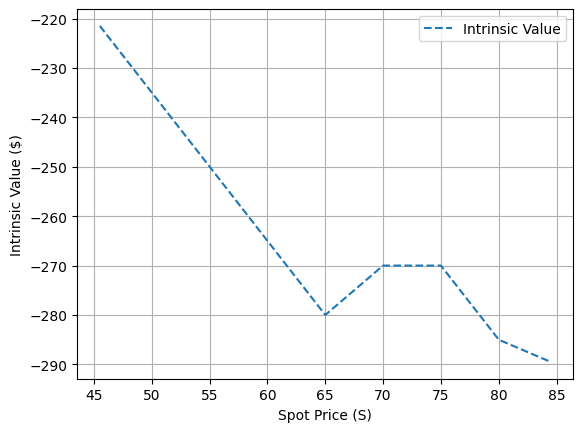

In [19]:
S = 65
spots = np.linspace(0.00, S * 2, 1000)
spots = np.linspace(S*0.70, S * 1.30, 1000)

strategy = [(65, "C", 3), (65, "P", 2),(70, "C", 2), (70, "P", -4),
            (75, "C", -6),(75, "P", 3),(80, "C", 4), (80, "P", -2), (0,"S",-4)]
IV = [option_graph(k[0], k[1] , k[2], spots) for k in strategy] 

Butterfly_spread = [(65, "C", -1), (70, "C", 2), (75, "C", -1)]
IV2 = [option_graph(k[0], k[1] , k[2], spots) for k in Butterfly_spread] 

Total_IV = np.sum(IV, axis=0)
IV_BF = np.sum(IV2, axis=0)

# 5. Plotting

plt.plot(spots, Total_IV, label="Intrinsic Value", linestyle="--")
#plt.plot(spots,IV_BF , label="Intrinsic Value", linestyle="--")
plt.xlabel("Spot Price (S)")
plt.ylabel("Intrinsic Value ($)")
plt.legend()
plt.grid()
plt.show()